# Exploratory Data Analysis (EDA)

## Objective

The goal of this notebook is to understand the dataset, identify data quality issues, explore feature distributions, and discover relationships between customer characteristics and loan default risk.

The analysis is divided into two stages:

1. Initial Data Exploration
2. Business-Oriented Exploratory Analysis

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

Loading Data

In [2]:
df = pd.read_csv("../Data/Raw/GiveMeSomeCredit-training.csv")

# Create a copy for analysis
credit_df = df.copy()

In [3]:
credit_df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
credit_df.tail()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0
149999,150000,0,0.850283,64,0,0.249908,8158.0,8,0,2,0,0.0


In [5]:
rows, cols = credit_df.shape

print(f"Number of Rows : {rows}")
print(f"Number of Columns : {cols}")

Number of Rows : 150000
Number of Columns : 12


In [6]:
credit_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

In [7]:
credit_df.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='str')

In [8]:
credit_df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [9]:
missing = credit_df.isnull().sum()

missing = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": round((missing / len(credit_df)) * 100, 2)
})

missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62
Unnamed: 0,0,0.00
SeriousDlqin2yrs,0,0.00
age,0,0.00
...,...,...
NumberOfTime30-59DaysPastDueNotWorse,0,0.00
NumberOfOpenCreditLinesAndLoans,0,0.00
NumberOfTimes90DaysLate,0,0.00
NumberRealEstateLoansOrLines,0,0.00


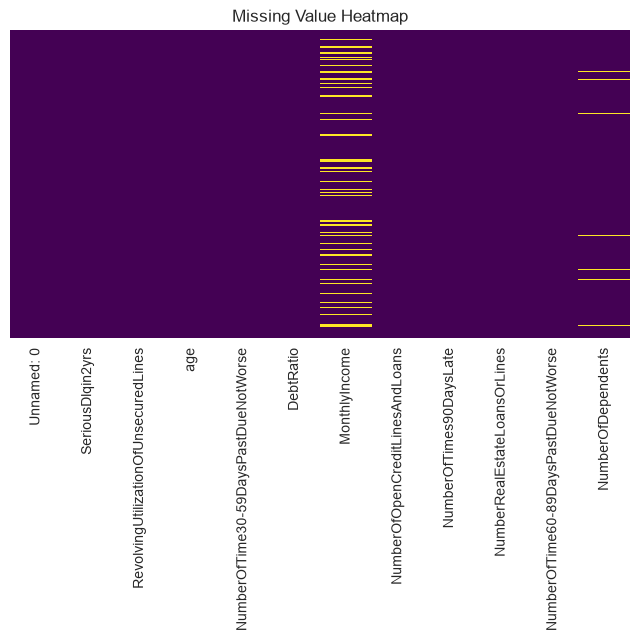

In [10]:
plt.figure(figsize=(8,4))

sns.heatmap(
    credit_df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")
plt.show()

In [11]:
duplicates = credit_df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [12]:
credit_df["SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

In [13]:
target_distribution = (
    credit_df["SeriousDlqin2yrs"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_distribution

SeriousDlqin2yrs
0    93.32
1     6.68
Name: proportion, dtype: float64

In [14]:
target_summary = pd.DataFrame({
    "Count": credit_df["SeriousDlqin2yrs"].value_counts(),
    "Percentage (%)": target_distribution
})

target_summary

,Count,Percentage (%)
SeriousDlqin2yrs,,
0,139974,93.32
1,10026,6.68


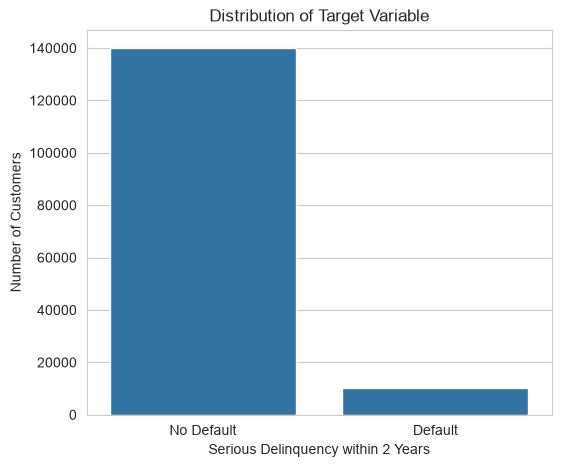

In [15]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=credit_df,
    x="SeriousDlqin2yrs"
)

plt.title("Distribution of Target Variable")
plt.xlabel("Serious Delinquency within 2 Years")
plt.ylabel("Number of Customers")

plt.xticks([0,1], ["No Default", "Default"])

plt.show()

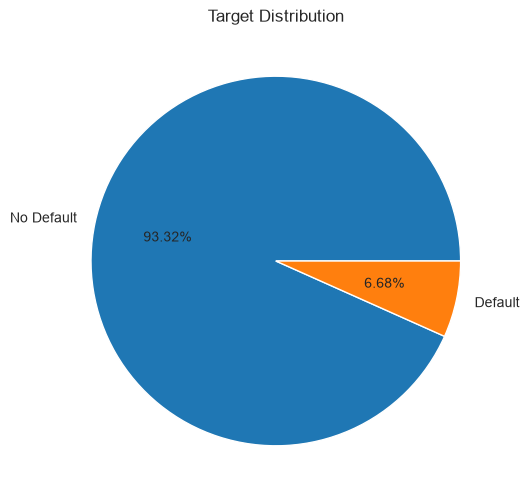

In [16]:
credit_df["SeriousDlqin2yrs"].value_counts().plot(
    kind="pie",
    autopct="%1.2f%%",
    labels=["No Default","Default"],
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Target Distribution")

plt.show()

In [17]:
target_summary

,Count,Percentage (%)
SeriousDlqin2yrs,,
0,139974,93.32
1,10026,6.68


In [18]:
majority = target_summary["Count"].max()
minority = target_summary["Count"].min()

print(f"Imbalance Ratio: {majority/minority:.2f} : 1")

Imbalance Ratio: 13.96 : 1


### Observations

- The target variable is highly imbalanced.
- Approximately **93.32%** of customers did not experience serious delinquency, while only **6.68%** did.
- This distribution reflects real-world banking scenarios, where the majority of approved borrowers repay their loans.
- Due to the imbalance, **accuracy alone is not an appropriate evaluation metric**, as a model predicting every customer as "No Default" would still achieve over 93% accuracy.
- Therefore, evaluation metrics such as **Precision, Recall, F1-score, and ROC-AUC** will be used to better assess model performance.

#### EDA-PART-2 

# Feature Analysis 1: NumberOfTimes90DaysLate

## Business Question

Does a customer's history of serious (90+ day) late payments increase the likelihood of future serious delinquency?

Repeated severe late payments indicate financial distress and are expected to be one of the strongest predictors of default risk.

In [19]:
credit_df["NumberOfTimes90DaysLate"].describe()

count    150000.000000
mean          0.265973
std           4.169304
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          98.000000
Name: NumberOfTimes90DaysLate, dtype: float64

In [20]:
credit_df["NumberOfTimes90DaysLate"].value_counts().sort_index().head(20)

NumberOfTimes90DaysLate
0     141662
1       5243
2       1555
3        667
4        291
       ...  
14         2
15         2
17         1
96         5
98       264
Name: count, Length: 19, dtype: int64

In [21]:
credit_df["NumberOfTimes90DaysLate"].value_counts().sort_index().tail(10)

NumberOfTimes90DaysLate
9      19
10      8
11      5
12      2
13      4
14      2
15      2
17      1
96      5
98    264
Name: count, dtype: int64

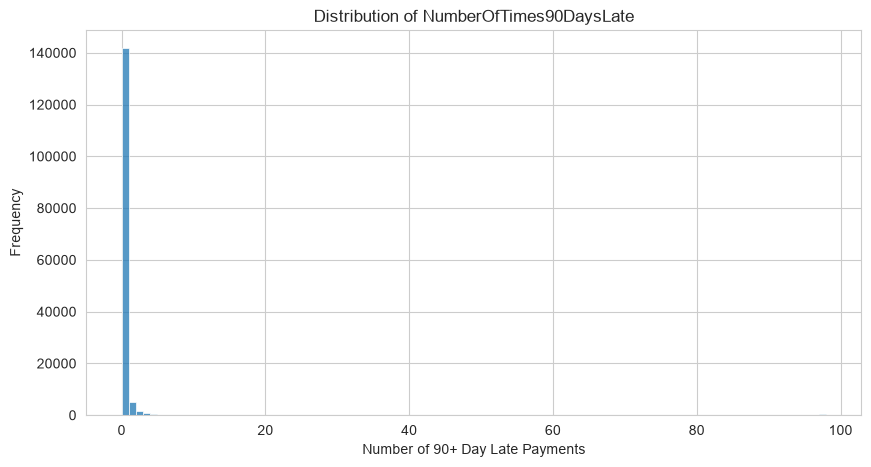

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
    credit_df["NumberOfTimes90DaysLate"],
    bins=100
)

plt.title("Distribution of NumberOfTimes90DaysLate")
plt.xlabel("Number of 90+ Day Late Payments")
plt.ylabel("Frequency")

plt.show()

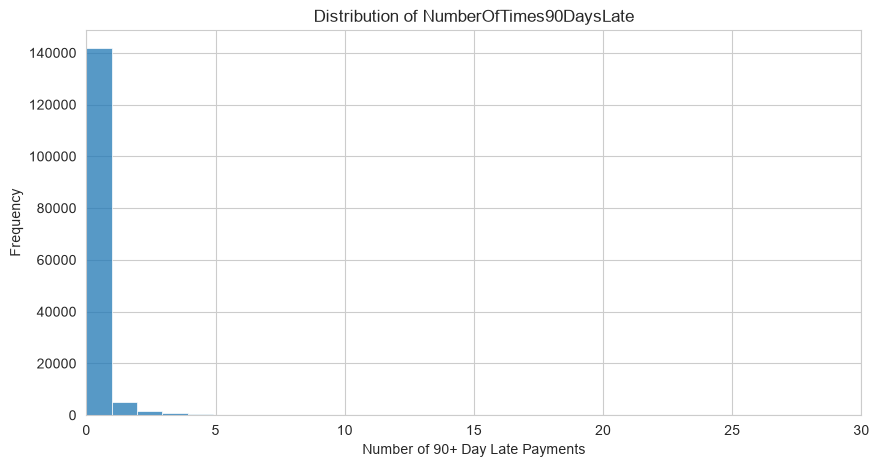

In [28]:
plt.figure(figsize=(10,5))

sns.histplot(
    credit_df["NumberOfTimes90DaysLate"],
    bins=100
)
plt.xlim(0,30)
plt.title("Distribution of NumberOfTimes90DaysLate")
plt.xlabel("Number of 90+ Day Late Payments")
plt.ylabel("Frequency")

plt.show()

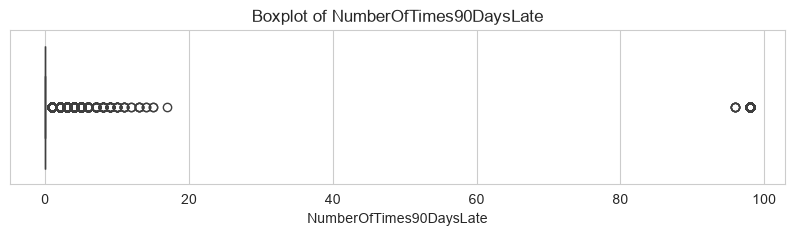

In [29]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=credit_df["NumberOfTimes90DaysLate"]
)

plt.title("Boxplot of NumberOfTimes90DaysLate")

plt.show()

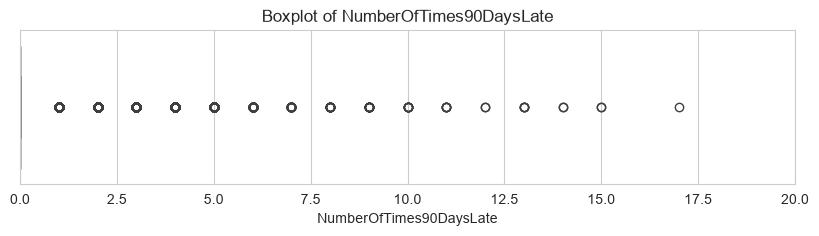

In [33]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=credit_df["NumberOfTimes90DaysLate"]
)
plt.xlim(0,20)
plt.title("Boxplot of NumberOfTimes90DaysLate")

plt.show()

In [38]:
filtered_data = credit_df.loc[
    credit_df["NumberOfTimes90DaysLate"] < 20,
    "NumberOfTimes90DaysLate"
]

print(f"Original rows : {len(credit_df)}")
print(f"Filtered rows : {len(filtered_data)}")

Original rows : 150000
Filtered rows : 149731


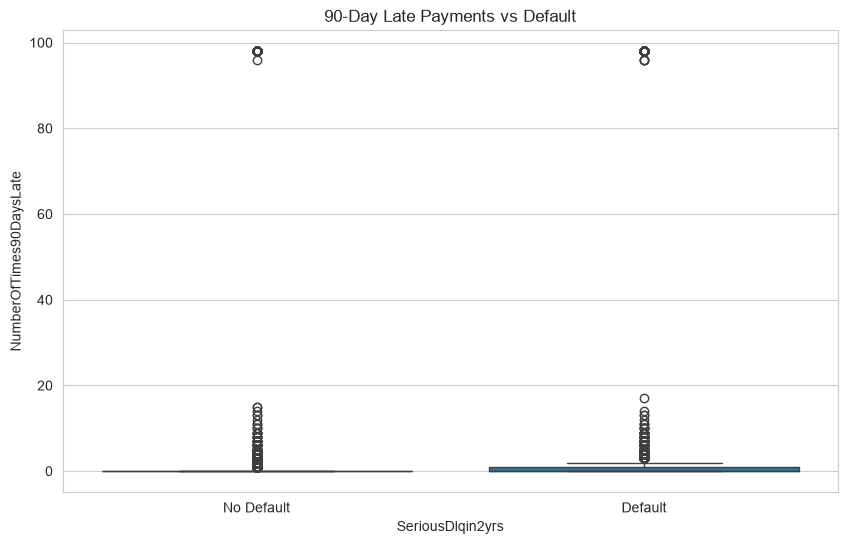

In [25]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=credit_df,
    x="SeriousDlqin2yrs",
    y="NumberOfTimes90DaysLate"
)

plt.xticks([0,1], ["No Default","Default"])

plt.title("90-Day Late Payments vs Default")

plt.show()

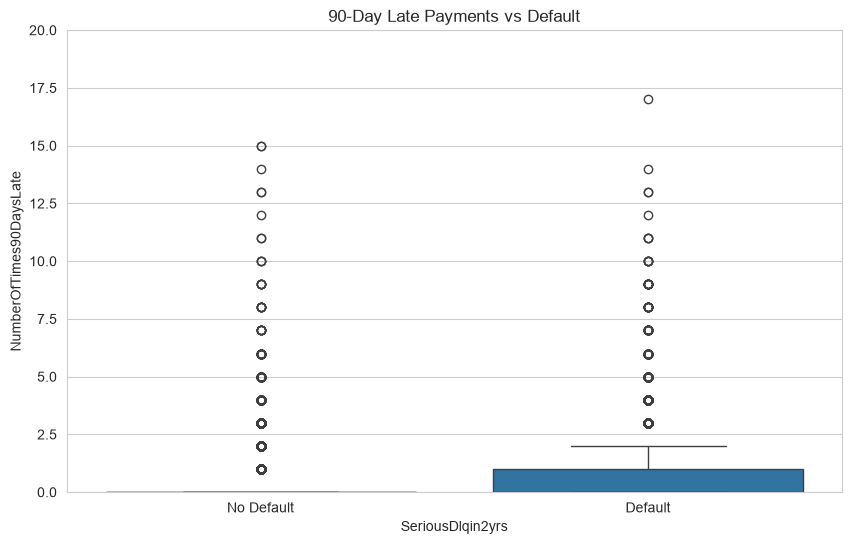

In [37]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=credit_df,
    x="SeriousDlqin2yrs",
    y="NumberOfTimes90DaysLate"
)
plt.ylim(0,20)
plt.xticks([0,1], ["No Default","Default"])

plt.title("90-Day Late Payments vs Default")

plt.show()

In [26]:
late_payment_default = (
    credit_df
    .groupby("NumberOfTimes90DaysLate")["SeriousDlqin2yrs"]
    .mean()
    .reset_index()
)

late_payment_default.head(15)

,NumberOfTimes90DaysLate,SeriousDlqin2yrs
0,0,0.046265
1,1,0.336639
2,2,0.499035
3,3,0.577211
4,4,0.670103
...,...,...
10,10,0.625000
11,11,0.600000
12,12,0.500000
13,13,0.500000


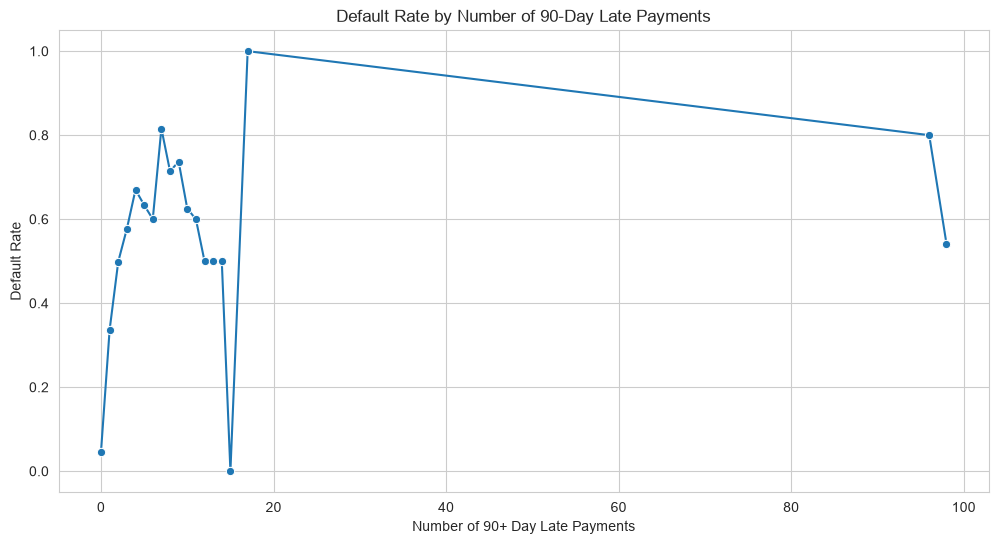

In [27]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=late_payment_default,
    x="NumberOfTimes90DaysLate",
    y="SeriousDlqin2yrs",
    marker="o"
)

plt.ylabel("Default Rate")
plt.xlabel("Number of 90+ Day Late Payments")
plt.title("Default Rate by Number of 90-Day Late Payments")

plt.show()

### Observations

- Approximately **94.4%** of customers have no history of being 90 or more days late.
- The distribution is highly right-skewed, with most observations concentrated at zero.
- A small number of observations contain extremely high values (e.g., 96 and 98), which are likely anomalous and require further investigation during preprocessing.
- The default rate increases sharply with the number of previous 90-day late payments. Customers with one or more severe delinquencies exhibit a substantially higher probability of future default compared to customers with no prior severe delinquencies.
- These findings suggest that repayment history is one of the strongest predictors of future credit risk.

# Data Quality Investigation

## Objective

During the initial EDA, unusually high values (such as 96 and 98) were observed in the delinquency-related features.

The objective of this section is to investigate whether these values represent genuine customer behaviour, data entry errors, or placeholder values before deciding how to handle them during preprocessing.

In [41]:
delinquency_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

In [42]:
credit_df[delinquency_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.0,0.0,0.0,98.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.0,0.0,0.0,98.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.0,0.0,0.0,98.0


In [43]:
for col in delinquency_cols:
    print(f"\n{col}")
    print("-"*50)

    print(
        credit_df[col]
        .value_counts()
        .sort_index()
        .tail(10)
    )


NumberOfTime30-59DaysPastDueNotWorse
--------------------------------------------------
NumberOfTime30-59DaysPastDueNotWorse
6     140
7      54
8      25
9      12
10      4
11      1
12      2
13      1
96      5
98    264
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse
--------------------------------------------------
NumberOfTime60-89DaysPastDueNotWorse
3     318
4     105
5      34
6      16
7       9
8       2
9       1
11      1
96      5
98    264
Name: count, dtype: int64

NumberOfTimes90DaysLate
--------------------------------------------------
NumberOfTimes90DaysLate
9      19
10      8
11      5
12      2
13      4
14      2
15      2
17      1
96      5
98    264
Name: count, dtype: int64


In [45]:
for col in delinquency_cols:
    print(f"{col}")

    print(
        (credit_df[col] >= 90).sum()
    )

    print()

NumberOfTime30-59DaysPastDueNotWorse
269

NumberOfTime60-89DaysPastDueNotWorse
269

NumberOfTimes90DaysLate
269



In [46]:
credit_df.loc[
    (credit_df["NumberOfTime30-59DaysPastDueNotWorse"] >= 90) |
    (credit_df["NumberOfTime60-89DaysPastDueNotWorse"] >= 90) |
    (credit_df["NumberOfTimes90DaysLate"] >= 90),
    delinquency_cols + ["SeriousDlqin2yrs"]
].head(20)

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,SeriousDlqin2yrs
1733,98,98,98,1
2286,98,98,98,0
3884,98,98,98,0
4417,98,98,98,0
4705,98,98,98,0
...,...,...,...,...
10245,98,98,98,1
11161,98,98,98,1
11362,98,98,98,1
12021,98,98,98,0


In [47]:
anomaly_rows = credit_df[
    (credit_df["NumberOfTime30-59DaysPastDueNotWorse"] >= 90) |
    (credit_df["NumberOfTime60-89DaysPastDueNotWorse"] >= 90) |
    (credit_df["NumberOfTimes90DaysLate"] >= 90)
]

print(f"Total suspicious rows: {len(anomaly_rows)}")

Total suspicious rows: 269


In [48]:
print(f"Percentage of dataset: {(len(anomaly_rows)/len(credit_df))*100:.2f}%")

Percentage of dataset: 0.18%


In [49]:
anomaly_rows["SeriousDlqin2yrs"].value_counts(normalize=True)*100

SeriousDlqin2yrs
1    54.64684
0    45.35316
Name: proportion, dtype: float64

### Findings

- The values **96** and **98** appear consistently across all three delinquency-related features.
- These anomalous values occur in the **same 269 customer records (0.18% of the dataset)**.
- Such a pattern is highly unlikely to represent genuine counts of late payments and suggests that these values may be placeholder codes or data quality anomalies.
- Customers with these anomalous values exhibit a substantially higher observed default rate (approximately **54.6%**) compared to the overall dataset (**6.68%**).
- These observations will be considered during the preprocessing stage before model training.